In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        # Total de parámetros: W1, b1, W2, b2
        self.num_params = (input_size * hidden_size) + hidden_size + \
                          (hidden_size * output_size) + output_size

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def decode_weights(self, weights_vector):
        """Convierte el vector 1D de la abeja en las matrices de la red."""
        idx = 0
        
        W1_end = self.input_size * self.hidden_size
        W1 = weights_vector[idx:idx+W1_end].reshape(self.input_size, self.hidden_size)
        idx += W1_end
        
        b1_end = self.hidden_size
        b1 = weights_vector[idx:idx+b1_end].reshape(1, self.hidden_size)
        idx += b1_end
        
        W2_end = self.hidden_size * self.output_size
        W2 = weights_vector[idx:idx+W2_end].reshape(self.hidden_size, self.output_size)
        idx += W2_end
        
        b2 = weights_vector[idx:].reshape(1, self.output_size)
        
        return W1, b1, W2, b2

    def forward(self, X, weights_vector):
        """Paso hacia adelante de la red neuronal."""
        W1, b1, W2, b2 = self.decode_weights(weights_vector)
        
        # Capa oculta
        Z1 = np.dot(X, W1) + b1
        A1 = self._sigmoid(Z1)
        
        # Capa de salida
        Z2 = np.dot(A1, W2) + b2
        A2 = self._softmax(Z2)
        
        return A2

    def compute_mse(self, X, y_true, weights_vector):
        """Calcula el Error Cuadrático Medio."""
        y_pred = self.forward(X, weights_vector)
        return np.mean(np.square(y_true - y_pred))

In [3]:
class ABC_Optimizer:
    def __init__(self, mlp, X_train, y_train, colony_size=40, max_iter=200, limit=20, bounds=(-5, 5)):
        self.mlp = mlp
        self.X_train = X_train
        self.y_train = y_train
        self.colony_size = colony_size
        self.num_employed = colony_size // 2
        self.num_onlookers = colony_size // 2
        self.max_iter = max_iter
        self.limit = limit
        self.bounds = bounds
        
        self.dim = mlp.num_params
        self.population = np.random.uniform(bounds[0], bounds[1], (self.num_employed, self.dim))
        self.fitness = np.zeros(self.num_employed)
        self.trials = np.zeros(self.num_employed)
        self.errors = np.zeros(self.num_employed)
        
        self.best_solution = None
        self.best_fitness = -1
        self.best_error = float('inf')
        self.history = [] # Para graficar convergencia

    def _calculate_fitness(self, error):
        """A menor error, mayor aptitud (fitness)."""
        if error >= 0:
            return 1 / (1 + error)
        else:
            return 1 + abs(error)

    def evaluate_population(self):
        for i in range(self.num_employed):
            self.errors[i] = self.mlp.compute_mse(self.X_train, self.y_train, self.population[i])
            self.fitness[i] = self._calculate_fitness(self.errors[i])
            
            if self.fitness[i] > self.best_fitness:
                self.best_fitness = self.fitness[i]
                self.best_solution = np.copy(self.population[i])
                self.best_error = self.errors[i]

    def _explore_neighborhood(self, i):
        """Genera una nueva fuente de alimento basada en la ecuación de movimiento ABC."""
        k = np.random.choice([j for j in range(self.num_employed) if j != i])
        phi = np.random.uniform(-1, 1, self.dim)
        
        new_solution = self.population[i] + phi * (self.population[i] - self.population[k])
        new_solution = np.clip(new_solution, self.bounds[0], self.bounds[1])
        
        new_error = self.mlp.compute_mse(self.X_train, self.y_train, new_solution)
        new_fitness = self._calculate_fitness(new_error)
        
        # Selección codiciosa (Greedy selection)
        if new_fitness > self.fitness[i]:
            self.population[i] = new_solution
            self.fitness[i] = new_fitness
            self.errors[i] = new_error
            self.trials[i] = 0
            
            if new_fitness > self.best_fitness:
                self.best_fitness = new_fitness
                self.best_solution = np.copy(new_solution)
                self.best_error = new_error
        else:
            self.trials[i] += 1

    def optimize(self):
        self.evaluate_population()
        
        for iteration in range(self.max_iter):
            # Fase de Abejas Empleadas
            for i in range(self.num_employed):
                self._explore_neighborhood(i)
                
            # Fase de Abejas Observadoras
            prob = self.fitness / np.sum(self.fitness)
            for _ in range(self.num_onlookers):
                # Selección de la ruleta
                i = np.random.choice(range(self.num_employed), p=prob)
                self._explore_neighborhood(i)
                
            # Fase de Abejas Exploradoras
            for i in range(self.num_employed):
                if self.trials[i] >= self.limit:
                    self.population[i] = np.random.uniform(self.bounds[0], self.bounds[1], self.dim)
                    self.errors[i] = self.mlp.compute_mse(self.X_train, self.y_train, self.population[i])
                    self.fitness[i] = self._calculate_fitness(self.errors[i])
                    self.trials[i] = 0
            
            self.history.append(self.best_error)
            if (iteration + 1) % 20 == 0:
                print(f"Iteración {iteration+1}/{self.max_iter} - Mejor Error (MSE): {self.best_error:.4f}")
                
        return self.best_solution, self.history

Iniciando optimización ABC. Total de parámetros a optimizar: 43
Iteración 20/300 - Mejor Error (MSE): 0.0506
Iteración 40/300 - Mejor Error (MSE): 0.0406
Iteración 60/300 - Mejor Error (MSE): 0.0406
Iteración 80/300 - Mejor Error (MSE): 0.0367
Iteración 100/300 - Mejor Error (MSE): 0.0367
Iteración 120/300 - Mejor Error (MSE): 0.0367
Iteración 140/300 - Mejor Error (MSE): 0.0324
Iteración 160/300 - Mejor Error (MSE): 0.0324
Iteración 180/300 - Mejor Error (MSE): 0.0324
Iteración 200/300 - Mejor Error (MSE): 0.0324
Iteración 220/300 - Mejor Error (MSE): 0.0324
Iteración 240/300 - Mejor Error (MSE): 0.0324
Iteración 260/300 - Mejor Error (MSE): 0.0324
Iteración 280/300 - Mejor Error (MSE): 0.0324
Iteración 300/300 - Mejor Error (MSE): 0.0324

Entrenamiento Finalizado.
Precisión en conjunto de prueba (Accuracy): 93.33%


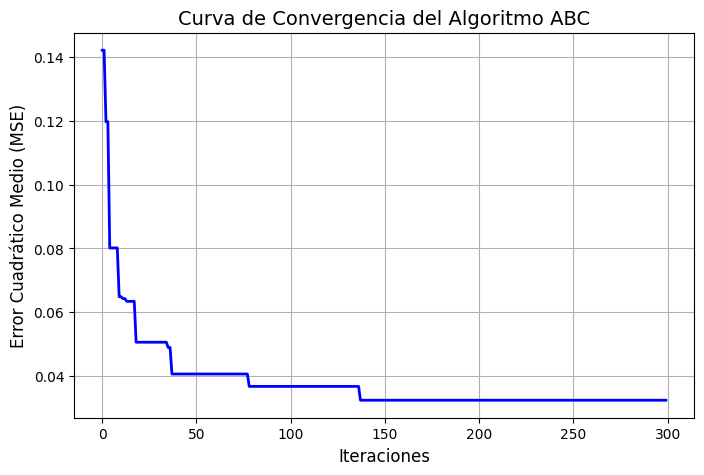

In [4]:
if __name__ == "__main__":
    # Cargar y preparar Dataset Iris
    iris = load_iris()
    X = iris.data
    y = iris.target.reshape(-1, 1)

    # Escalado de datos y One-Hot Encoding
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    encoder = OneHotEncoder(sparse_output=False)
    y_encoded = encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

    # Configuración de la red (4 entradas, 5 ocultas, 3 salidas)
    input_size = X_train.shape[1]
    hidden_size = 5
    output_size = y_train.shape[1]
    
    mlp = MLP(input_size, hidden_size, output_size)
    print(f"Iniciando optimización ABC. Total de parámetros a optimizar: {mlp.num_params}")

    # Inicializar y correr optimizador ABC
    abc = ABC_Optimizer(mlp, X_train, y_train, colony_size=50, max_iter=300, limit=30)
    best_weights, error_history = abc.optimize()

    # Evaluación en Test
    y_pred_test = mlp.forward(X_test, best_weights)
    predictions = np.argmax(y_pred_test, axis=1)
    true_labels = np.argmax(y_test, axis=1)
    accuracy = np.mean(predictions == true_labels)
    
    print(f"\nEntrenamiento Finalizado.")
    print(f"Precisión en conjunto de prueba (Accuracy): {accuracy * 100:.2f}%")

    # Graficar convergencia
    plt.figure(figsize=(8, 5))
    plt.plot(error_history, color='b', linewidth=2)
    plt.title('Curva de Convergencia del Algoritmo ABC', fontsize=14)
    plt.xlabel('Iteraciones', fontsize=12)
    plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
    plt.grid(True)
    plt.show()